# Part 4, Task 3 — Generative Adversarial Network (GAN)
COMP3710 Lab Demonstration 2

**Important:** the real target (Preprocessed OASIS brain MRI) lives only at
`/home/groups/comp3710/` on Rangpur — not available on this laptop. The lab sheet itself
recommends starting GANs on MNIST before attempting OASIS ("You might want to start out using the
MNIST digit dataset or the CelebA dataset first for GANs before attempting it with the OASIS
dataset"), so this notebook is not a workaround — it's exactly the recommended first step,
followed by a "porting to Rangpur" section for what changes to point the same code at OASIS.

GANs are notoriously unstable to train (the lab sheet warns about this directly). This notebook
trains at a scale that finishes on a laptop in a few minutes, tracks both networks' losses, and
snapshots generated samples at several points during training as direct evidence of what was and
wasn't learned, and where things start to go wrong if they do.

## 4.3.1 The idea: two networks playing a game against each other

- **Generator (G)**: takes a vector of random noise as input, and tries to turn it into an image
  that looks like it came from the real dataset.
- **Discriminator (D)**: takes an image (real or generated) and tries to predict whether it's real
  or fake.

They are trained *simultaneously*, against each other:
- D is trained to get better at telling real from fake.
- G is trained to get better at fooling D.

Neither network ever sees the other's *parameters* directly — each only sees the other's
*outputs*, and adapts. If training goes well, G is pushed to produce increasingly realistic images
because that is the only way to keep fooling an increasingly competent D. There is no "ground
truth target image" for G to copy — it only ever gets a real/fake signal from D. This adversarial
setup (as opposed to a VAE's direct reconstruction-error signal) is both GANs' main strength (no
blurring, unlike a VAE's reconstruction loss) and the source of most of their notorious training
instability (there's no fixed target either network is converging towards — they are both moving,
so the training dynamics are a good deal less predictable than ordinary supervised training).

## 4.3.2 Data

In [1]:
import time
import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

LATENT_DIM = 100

# Generator ends in tanh() (outputs in [-1, 1]), so normalize real images to match that range
# rather than the [0, 1] used for the VAE/UNet earlier.
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.5], [0.5])])
train_ds = torchvision.datasets.MNIST(root="/tmp/mnist_data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, drop_last=True)
print("train size:", len(train_ds))

device: mps
train size: 60000


## 4.3.3 Generator and Discriminator

**Generator**: the mirror image of a normal CNN — instead of shrinking an image down to a
prediction, it *grows* a small random vector up into a full image, via transposed convolutions
(the same upsampling operation used in the VAE decoder and UNet's decoder path). Ends in `tanh`
so every output pixel lands in `[-1, 1]`, matching the normalised real images.

**Discriminator**: an ordinary small CNN binary classifier — shrinks an image down via strided
convolutions, ending in a single sigmoid output: the probability the input image is real.
`LeakyReLU` (rather than plain `ReLU`) is the standard choice here, since it doesn't have plain
ReLU's "dead unit" failure mode (a unit whose output is 0 for every input has zero gradient and
never updates again), which is worth avoiding in a network already prone to unstable training.

In [2]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 128 * 7 * 7)
        self.net = nn.Sequential(
            nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),   # 7x7 -> 14x14
            nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, 4, stride=2, padding=1),     # 14x14 -> 28x28
            nn.Tanh(),
        )

    def forward(self, z):
        h = self.fc(z).view(-1, 128, 7, 7)
        return self.net(h)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 4, stride=2, padding=1), nn.LeakyReLU(0.2, True),                          # 28->14
            nn.Conv2d(64, 128, 4, stride=2, padding=1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, True),    # 14->7
        )
        self.fc = nn.Linear(128 * 7 * 7, 1)

    def forward(self, x):
        h = self.net(x).flatten(1)
        return torch.sigmoid(self.fc(h))


G = Generator(LATENT_DIM).to(device)
D = Discriminator().to(device)
print("Generator params:", sum(p.numel() for p in G.parameters()))
print("Discriminator params:", sum(p.numel() for p in D.parameters()))

Generator params: 766017
Discriminator params: 138817


## 4.3.4 The training loop — two optimisers, one batch, two updates

Each batch does **two separate backward passes and optimiser steps** — one for D, one for G:

1. **Update D**: show it a batch of real images (label 1) and a batch of freshly generated fake
   images (label 0, and note `.detach()` — gradients must *not* flow back into G during D's
   update, since this step is only supposed to improve D). D's loss is standard binary
   cross-entropy for "was this real or fake".
2. **Update G**: generate a *new* batch of fakes, run them through the (now just-updated) D, and
   train G to make D output "real" (label 1) for them — this is the "non-saturating" trick: rather
   than literally minimising "fool the discriminator" (which has a very weak gradient early in
   training, when D easily spots obvious fakes), G is trained to directly maximise D's real-ness
   score for its own fakes, which gives a much stronger and more useful training signal.

In [3]:
opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
loss_fn = nn.BCELoss()

# A FIXED noise vector, reused every snapshot, so we can watch the *same* points in latent
# space evolve into sharper digits over training, rather than a fresh random image each time.
fixed_noise = torch.randn(64, LATENT_DIM, device=device)

def sample_grid(generator, noise, n_row=8):
    generator.eval()
    with torch.no_grad():
        imgs = generator(noise).cpu()
    imgs = (imgs + 1) / 2   # undo the [-1, 1] normalisation for display
    generator.train()
    n = imgs.size(0)
    n_col = n // n_row
    canvas = np.zeros((28 * n_row, 28 * n_col))
    for idx in range(n):
        r, c = idx // n_col, idx % n_col
        canvas[r * 28:(r + 1) * 28, c * 28:(c + 1) * 28] = imgs[idx, 0].numpy()
    return canvas


n_epochs = 30
snapshot_epochs = {0, 2, 5, 10, 20, 29}
snapshots = {}
history = {"loss_D": [], "loss_G": []}

t0 = time.time()
for epoch in range(n_epochs):
    epoch_loss_D, epoch_loss_G, n_batches = 0.0, 0.0, 0
    for real, _ in train_loader:
        real = real.to(device)
        bs = real.size(0)
        real_labels = torch.ones(bs, 1, device=device)
        fake_labels = torch.zeros(bs, 1, device=device)

        # --- Discriminator update ---
        opt_D.zero_grad()
        loss_d_real = loss_fn(D(real), real_labels)
        z = torch.randn(bs, LATENT_DIM, device=device)
        fake = G(z)
        loss_d_fake = loss_fn(D(fake.detach()), fake_labels)
        loss_d = loss_d_real + loss_d_fake
        loss_d.backward()
        opt_D.step()

        # --- Generator update ---
        opt_G.zero_grad()
        loss_g = loss_fn(D(fake), real_labels)   # non-saturating trick
        loss_g.backward()
        opt_G.step()

        epoch_loss_D += loss_d.item()
        epoch_loss_G += loss_g.item()
        n_batches += 1

    history["loss_D"].append(epoch_loss_D / n_batches)
    history["loss_G"].append(epoch_loss_G / n_batches)
    print(f"epoch {epoch:2d}: loss_D={history['loss_D'][-1]:.4f}  loss_G={history['loss_G'][-1]:.4f}")

    if epoch in snapshot_epochs:
        snapshots[epoch] = sample_grid(G, fixed_noise)

print(f"\nTraining time: {time.time() - t0:.2f}s on {device}")

epoch  0: loss_D=0.2745  loss_G=3.4890


epoch  1: loss_D=0.2686  loss_G=2.6060


epoch  2: loss_D=0.2373  loss_G=2.9745


epoch  3: loss_D=0.2759  loss_G=2.8448


epoch  4: loss_D=0.2850  loss_G=2.8204


...

epoch 25: loss_D=0.4105  loss_G=2.8597


epoch 26: loss_D=0.3706  loss_G=2.8956


epoch 27: loss_D=0.4073  loss_G=2.8716


epoch 28: loss_D=0.3743  loss_G=2.9165


epoch 29: loss_D=0.4137  loss_G=2.8380

Training time: 744.81s on mps


## 4.3.5 Training curves

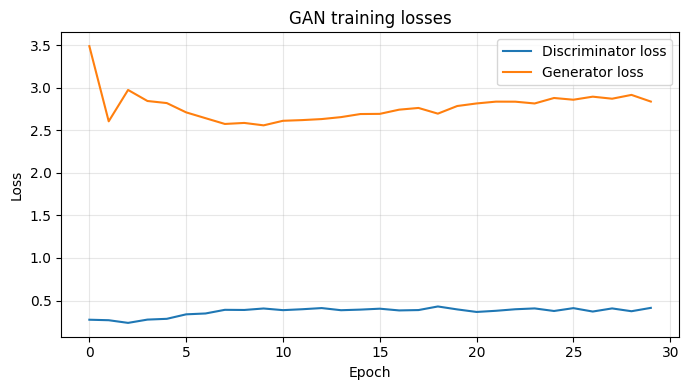

In [4]:
plt.figure(figsize=(7, 4))
plt.plot(history["loss_D"], label="Discriminator loss")
plt.plot(history["loss_G"], label="Generator loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("GAN training losses")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Reading GAN loss curves is genuinely different from reading a normal training-loss plot.**
In ordinary supervised training (Parts 1-3, and the VAE/UNet above), a falling loss is
unambiguously good news. Here, D's loss falling means D is winning (getting better at spotting
fakes) and G's loss falling means G is winning (successfully fooling D) — the two are in direct
opposition, so both curves *cannot* fall together indefinitely: if D "wins" too decisively, G's
gradient signal weakens and it stops improving; if G "wins" too easily, D stops giving it anything
useful to learn from either. **Neither loss reliably converging to a small, stable value is
actually a sign of failure the way it would be elsewhere** — some oscillation is expected and even
healthy for a GAN in a genuine back-and-forth contest. What matters more is the actual generated
images (next cell), not the loss curves in isolation.

## 4.3.6 Watching the generator improve over training

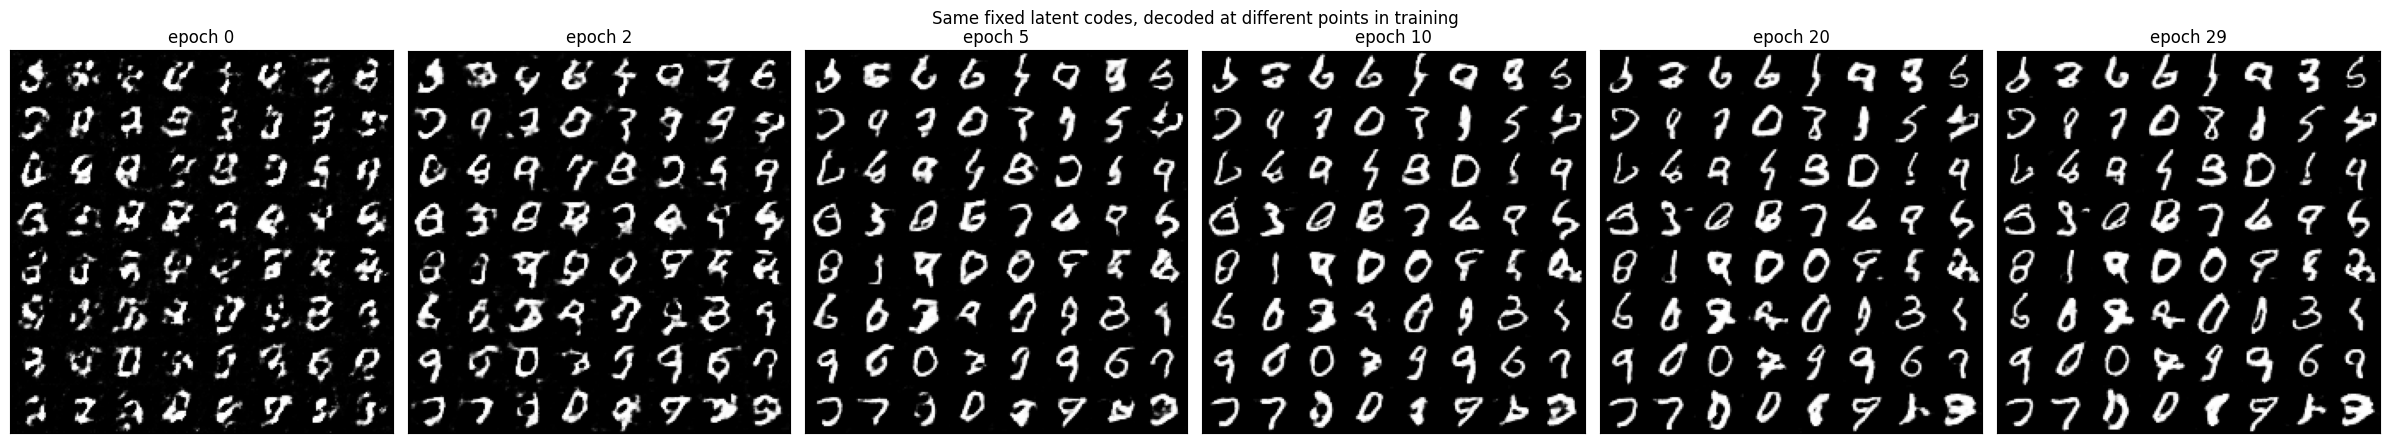

In [5]:
fig, axes = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 4.5))
for ax, epoch in zip(axes, sorted(snapshots.keys())):
    ax.imshow(snapshots[epoch], cmap="gray")
    ax.set_title(f"epoch {epoch}")
    ax.set_xticks(()); ax.set_yticks(())
plt.suptitle("Same fixed latent codes, decoded at different points in training")
plt.tight_layout()
plt.show()

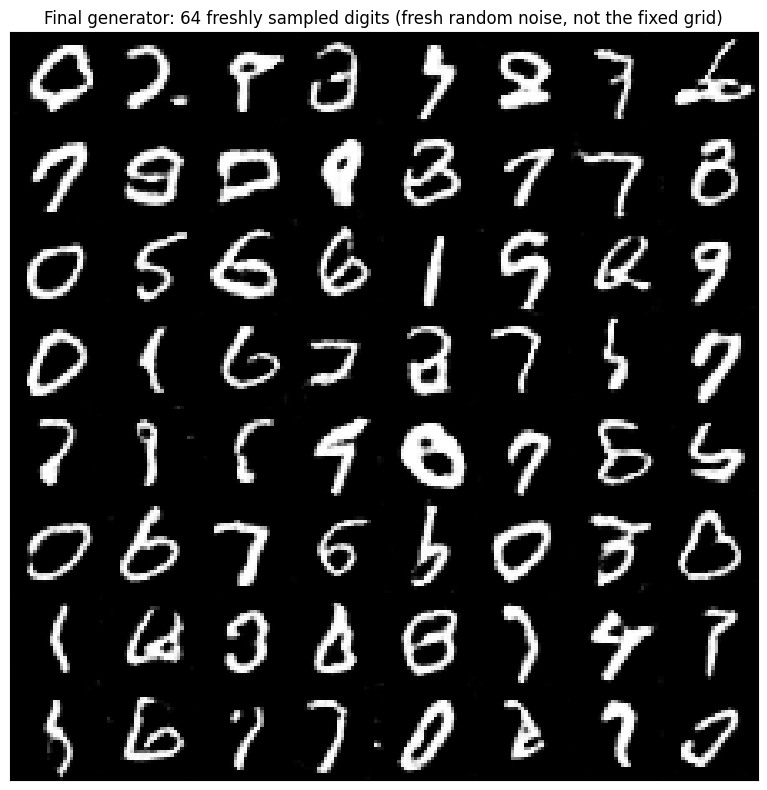

In [6]:
final_grid = sample_grid(G, torch.randn(64, LATENT_DIM, device=device))
plt.figure(figsize=(8, 8))
plt.imshow(final_grid, cmap="gray")
plt.title("Final generator: 64 freshly sampled digits (fresh random noise, not the fixed grid)")
plt.xticks(()); plt.yticks(())
plt.tight_layout()
plt.show()

**Discussion — reading the progression and checking for mode collapse:**

- Early snapshots (epoch 0-2) should look like unstructured grey noise — G hasn't learned anything
  useful yet, unsurprising this early.
- Middle snapshots should show blob-like shapes starting to resemble strokes, with digit-like
  structure emerging by the later epochs.
- **Mode collapse** (the specific failure the lab sheet warns about) is when G discovers a small
  handful of outputs that reliably fool D, and stops exploring anything else — every one of the 64
  samples in the final grid would look nearly identical (e.g. every image collapsing to the same
  '1' or '8'), regardless of the input noise. The fix, if this happens, is generally more training
  epochs, a lower learning rate, or a modified loss (e.g. Wasserstein GAN) — not something to fully
  solve here, but worth checking for and naming explicitly if it shows up, since the lab sheet
  explicitly calls it out as the main failure mode to watch for.
- The lab's full-marks bar ("results must look like unique brains... issues such as mode collapse
  need to be fully resolved") is set for the *actual OASIS run*, not this MNIST rehearsal — this
  notebook's job is to prove the GAN training loop itself is implemented correctly and produces
  genuine, non-collapsed variety, which is the right foundation to then point at OASIS.

## 4.3.7 Porting to Rangpur — OASIS instead of MNIST

Same pattern as Tasks 1 and 2: `Generator`, `Discriminator`, and the training loop are dataset
-agnostic. The changes needed:

```python
# Dataset: same OASISDataset-style class as Task 1/2 (confirm the real file layout on Rangpur)
oasis_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),   # keep matching the generator's tanh() output range
])
train_ds = OASISDataset("/home/groups/comp3710/OASIS/train", transform=oasis_transform)

# Generator/Discriminator: add another up/down-sampling stage if img_size > 28
# (each stage in this architecture halves/doubles resolution by a factor of 2 -- e.g. going from
# 28x28 to 128x128 needs roughly 2 more stages each, not just larger numbers in the existing ones)
```

**What actually needs to change:**

- **The dataset**: OASIS brain slices instead of MNIST digits (and check the real image size —
  almost certainly not 28x28).
- **Network depth**: the architectures above are sized for 28x28 outputs specifically (`7x7 ->
  14x14 -> 28x28`, two upsampling stages). A larger target resolution needs more stages added to
  both `Generator.net` and `Discriminator.net`, not just parameter tweaks — this is the main real
  implementation change, not just a config value like in Tasks 1-2.
- **Training length**: real anatomical structure is harder to learn than digit strokes; expect to
  need more epochs, and to watch more carefully for mode collapse than on MNIST.
- **`device="cuda"`**, as in every other part.
- The loss functions, the alternating D/G update pattern, and the snapshot-based "watch training
  progress" visualisation approach all carry over unchanged.